# Curating FPbase into the 758-sequence peak dataset

A visual account of how the full FPbase export becomes the curated **peak** dataset that
`build_dataset.py` writes to `data/peak/curated/`, and what that surviving set looks like.

1. **Sequence-space map** — t-SNE of a *max-pooled* ESM-2 embedding of every FPbase protein
   carrying a sequence (n = 990), with the 758 curated "true FPs" highlighted and the major
   lineages labelled by ancestral organism.
2. **Curation funnel** — where the other proteins go, stage by stage.
3. **Peak distribution** — excitation vs. emission for the 758, with marginal histograms.
4. **PCA on the peaks themselves** — what the two-dimensional (ex, em) target space looks like
   once rotated onto its principal axes.
5. **PCA on sequence embeddings** — restricted to the curated proteins that also have measured
   spectral curves.

Figures follow the **2026 Arcadia style guide**: Atkinson Hyperlegible Next for text (Medium 15pt
axis titles, Regular 15pt labels, ExtraLight 15pt Charcoal annotations, SemiBold 17pt key titles),
Atkinson Hyperlegible Mono 14.5pt for numerals, 0.75pt black axis lines with 5px ticks, 38pt
Chateau panel letters, the Arcadia primary/secondary palettes for categorical data with neutrals
for supporting elements, and the Arcadia magma gradient wherever emission wavelength is shaded
continuously. Per the guide, charts are **titled in the caption, not in the figure**.

> Run from `dataset_pipeline/`. Two one-off prerequisites:
> `python fetch_arcadia_fonts.py` (fonts, seconds) and
> `python embed_fpbase_maxpool.py` (embedding cache, a couple of minutes on GPU/MPS).

In [8]:
# The inline backend crops to "tight" by default, which silently rescales every figure and
# throws away the guide's panel dimensions. Turn it off so a 1000px panel really is 1000px.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

import hashlib
import json
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import arcadia_pycolor as apc

# The guide's weights only exist as separate faces after fetch_arcadia_fonts.py has run;
# without them matplotlib silently falls back to its defaults.
FONTS = "fonts"
apc.mpl.setup(font_dirpath=FONTS if os.path.isdir(FONTS) else None)
if not os.path.isdir(FONTS):
    print("NOTE: run `python fetch_arcadia_fonts.py` for the Atkinson Hyperlegible faces")

# apc sets figure.dpi to 72 so that one point equals one style-guide pixel. Keep that
# correspondence for layout, but render at 2x so the inline PNGs are not soft on screen.
# Exports via apc.mpl.save_figure still use the guide's 72dpi (web) / 300dpi (print).
plt.rcParams["figure.dpi"] = 144
RNG_SEED = 0

FPBASE    = "../fpbase-extractor/fpbase_output"
PROT_JSON = f"{FPBASE}/fpbase_proteins.json"
SPECTRA   = f"{FPBASE}/fpbase_spectra.json"
EMB_NPY   = "data/fpbase_esm2_650M_max.npy"
EMB_META  = "data/fpbase_esm2_650M_max.meta.json"
CURATED   = "data/peak/curated"

assert os.path.exists(EMB_NPY), "run `python embed_fpbase_maxpool.py` first"
print("environment ready")

environment ready


### Style-guide helpers

Panel geometry is expressed in the guide's pixels (Full_wide 1000, Float 650, Half_square 490 —
heights adjusted as needed, kept under the 1,200px limit). Since `arcadia_pycolor` pins the figure
DPI to 72, one matplotlib point is exactly one style-guide pixel, so a 15pt label really is 15px.

In [2]:
PX = 1 / 72                       # one style-guide pixel, expressed in inches
FULL_WIDE, FLOAT, HALF_SQUARE = 1000, 650, 490


def figure_px(width_px, height_px, **kwargs):
    '''plt.subplots with the figure sized in style-guide pixels.'''
    return plt.subplots(figsize=(width_px * PX, height_px * PX), **kwargs)


# Text roles, straight from the guide's "Text styles" page
PANEL_LETTER = dict(fontsize=38, fontweight="regular", color=str(apc.chateau))
ANNOTATION   = dict(fontsize=15, fontweight="ultralight", color=str(apc.charcoal))
NUMBERS      = dict(fontfamily="Atkinson Hyperlegible Mono", fontsize=14.5,
                    color=str(apc.black))
# an annotation that is mostly a number takes the numeral face, in annotation colour
NUMBER_NOTE  = dict(fontfamily="Atkinson Hyperlegible Mono", fontsize=14.5,
                    color=str(apc.charcoal))

# Data colors: Arcadia primary/secondary. Neutrals carry only supporting elements.
HIGHLIGHT, CONTRAST = str(apc.aegean), str(apc.amber)
NEUTRAL, NEUTRAL_SOFT = str(apc.chateau), str(apc.taupe)

# Continuous scale for emission wavelength. Magma is Arcadia's default gradient and one of the
# guide's sequential gradients for dots; its cool-to-warm run keeps short and long wavelengths
# reading the intuitive way round. The very top of the ramp is dropped because it approaches
# the page white and would make the reddest proteins disappear.
EM_CMAP = LinearSegmentedColormap.from_list(
    "apc:magma_dots", apc.gradients.magma.to_mpl_cmap()(np.linspace(0.04, 0.86, 256))
)


def panel_letter(ax, letter, dx=-46, dy=12):
    '''Place a panel letter at the top-left corner of an axes, in the guide's style.'''
    ax.annotate(letter, xy=(0, 1), xycoords="axes fraction",
                xytext=(dx, dy), textcoords="offset points",
                ha="left", va="bottom", annotation_clip=False, **PANEL_LETTER)


def key_block(key_ax, handles, title, ncol=1, entry_gap=None, title_fontsize=17,
              **legend_kwargs):
    '''Draw a key into a dedicated blank axes: SemiBold title over a 1.5pt Chateau rule.

    This replaces apc.mpl.add_legend_line, which does not fit this notebook on two counts:
    it inserts the rule into the legend's *first column* (stretching that column to the whole
    legend width when there is more than one), and it sizes the rule in display pixels while
    drawing in points, so the rule comes out too long whenever the figure DPI is not 72.
    Measuring the drawn legend instead gives a rule that ends at the longest label, as the
    guide asks, at any DPI and any number of columns.

    The title defaults to the guide's 17pt SemiBold over 15pt entries; a key with more entries
    than its panel can hold steps both down, and then the rule and the gap below the title
    follow the title size. Everything else (`fontsize`, `labelspacing`, ...) goes to `legend`.
    '''
    key_ax.axis("off")
    figure = key_ax.figure
    height_px = key_ax.get_position().height * figure.get_figheight() * 72
    entry_gap = 2 * title_fontsize if entry_gap is None else entry_gap

    def down(px):
        return 1 - px / height_px

    legend = key_ax.legend(handles=handles, loc="upper left", ncol=ncol,
                           bbox_to_anchor=(0, down(entry_gap)),
                           alignment="left", columnspacing=1.2, **legend_kwargs)
    key_ax.text(0, down(0), title, transform=key_ax.transAxes, ha="left", va="top",
                fontsize=title_fontsize, fontweight="semibold", color=str(apc.black))

    figure.canvas.draw()
    right = legend.get_window_extent().transformed(key_ax.transAxes.inverted()).x1
    key_ax.plot([0, right], [down(title_fontsize + 7)] * 2, transform=key_ax.transAxes,
                lw=1.5, color=str(apc.chateau), clip_on=False, solid_capstyle="butt")
    return legend


print("helpers defined")

helpers defined


## 1. The sequence-space map

### 1.1 Load the proteins, the max-pooled embedding, and the curated set

`embed_fpbase_maxpool.py` walks `fpbase_proteins.json` in order and embeds every entry that
carries a sequence, recording an md5 over that exact sequence list. Rebuilding the same list
here and checking the md5 guarantees each embedding row still lines up with a row of the table.

Membership in the curated set is matched **on the sequence**, not the slug: stage C of the
pipeline collapses each group of identical sequences to a single representative row, so slug
matching would miss the duplicates that were folded away.

In [3]:
proteins = json.load(open(PROT_JSON))
meta = json.load(open(EMB_META))

prot = pd.DataFrame([
    {
        "slug": p.get("slug", ""),
        "name": p.get("name", ""),
        "organism": p.get("parent_organism") or "",
        "seq": (p.get("seq") or "").strip().upper(),
    }
    for p in proteins
    if (p.get("seq") or "").strip()
])

md5 = hashlib.md5("\x00".join(prot.seq).encode()).hexdigest()
assert md5 == meta["seq_md5"], "embedding cache is stale -- rerun embed_fpbase_maxpool.py"

Z = np.load(EMB_NPY)
assert len(Z) == len(prot)

curated = pd.read_csv(f"{CURATED}/peaks_assignments.csv")
cmeta = json.load(open(f"{CURATED}/curate_meta.json"))
prot["is_true_fp"] = prot.seq.isin(set(curated.seq))

print(f"{len(proteins)} FPbase entries | {len(prot)} with a sequence | "
      f"embedding {Z.shape} ({meta['model']}, layer {meta['layer']}, {meta['pooling']}-pooled)")
print(f"curated peak set: {len(curated)} rows, {prot.is_true_fp.sum()} of the {len(prot)} "
      f"sequenced proteins map into it")

1041 FPbase entries | 990 with a sequence | embedding (990, 1280) (esm2_t33_650M_UR50D, layer 33, max-pooled)
curated peak set: 758 rows, 758 of the 990 sequenced proteins map into it


### 1.2 Assign each protein to a lineage by ancestral organism

FPbase records the `parent_organism` each protein was engineered from. Grouping on it recovers
the natural lineages: the *Aequorea* GFP family, the *Discosoma* DsRed / mFruits reds, the
*Entacmaea* eqFP line that produced mKate and mScarlet, and so on. Proteins whose ancestor is a
bacterial phytochrome are the biliverdin near-infrared FPs, which the pipeline excludes because
their chromophore is a supplied cofactor rather than something the sequence builds.

The assignment is a regex over that one field and nothing else — no sequence alignment, no
phylogeny. That makes it transparent and reproducible, but it inherits FPbase's own curation:
anything recorded as `synthetic construct` or left blank falls into *synthetic / unassigned*, and
a genus nobody wrote a rule for falls into *other*. Those two catch-alls are large (160 and 50
proteins) precisely because they are the residue of a deliberately conservative rule set.

**Colour follows biology, not an arbitrary palette.** Each lineage is drawn in the Arcadia colour
closest to what its *ancestral wild-type FP* actually emits — `avGFP` green for the *Aequorea*
family, `DsRed` orange-red for *Discosoma*, `zFP538` yellow for *Zoanthus*, and so on down to
near-infrared for the bacteriophytochromes. The founder of each lineage is its earliest-published
member, which is also FPbase's wild-type entry. The key is ordered by that founding emission
wavelength, so it reads bottom-to-top as a spectrum rather than by group size. Most FP lineages
were founded by a green protein, so the greens are separated by shade instead of hue. The two
catch-all groups take neutrals, since the guide reserves neutrals for supporting elements.

In [4]:
FAMILY_RULES = [
    ("GFP family — Aequorea",             r"Aequorea"),
    ("DsRed / mFruits — Discosoma",       r"Discosoma"),
    ("eqFP / mKate / mScarlet — Entacmaea", r"Entacmaea"),
    ("Faviina — Kaede / EosFP / Dendra",  r"Lobophyllia|Echinophyllia|Verrillofungia|Montastraea|"
                                          r"Favia|Trachyphyllia|Galaxea|Mycedium|Catalaphyllia|"
                                          r"Scleractinia|Platygyra|Cyphastrea|Dendronephthya"),
    ("Clavularia — mTFP / Kusabira",      r"Clavularia"),
    ("Zoanthus — ZsGreen / ZsYellow",     r"Zoanthus"),
    ("Acropora / Montipora corals",       r"Acropora|Montipora"),
    ("StayGold — Cytaeis",                r"Cytaeis"),
    ("LanYFP / mNeonGreen — Branchiostoma", r"Branchiostoma"),
    ("Bacteriophytochrome IR-FPs",        r"Rhodopseudomonas|Deinococcus|Bradyrhizobium|"
                                          r"Agrobacterium|Xanthomonas|Idiomarina"),
    ("Flavin-based (LOV / miniSOG)",      r"Arabidopsis|Bacillus|Pseudomonas"),
]


def family_of(org):
    for label, pat in FAMILY_RULES:
        if re.search(pat, org, re.I):
            return label
    return "synthetic / unassigned" if org in ("", "synthetic construct") else "other"


prot["family"] = prot.organism.map(family_of)

# Short forms for keys and on-plot callouts; at the guide's 15pt the full
# "lineage — ancestor" strings are too wide. The full mapping is the table below.
SHORT = {
    "GFP family — Aequorea":               "GFP family",
    "DsRed / mFruits — Discosoma":         "DsRed / mFruits",
    "eqFP / mKate / mScarlet — Entacmaea": "eqFP / mKate",
    "Faviina — Kaede / EosFP / Dendra":    "Faviina corals",
    "Clavularia — mTFP / Kusabira":        "Clavularia",
    "Zoanthus — ZsGreen / ZsYellow":       "Zoanthus",
    "Acropora / Montipora corals":         "Acropora",
    "StayGold — Cytaeis":                  "StayGold",
    "LanYFP / mNeonGreen — Branchiostoma": "LanYFP",
    "Bacteriophytochrome IR-FPs":          "Bacteriophytochrome",
    "Flavin-based (LOV / miniSOG)":        "Flavin-based LOV",
    "other":                               "Other",
    "synthetic / unassigned":              "Synthetic",
}

# Founding wild-type FP of each lineage, the emission it was reported at, and the Arcadia colour
# nearest that emission. Six lineages were founded by a green protein, so within the greens the
# colours are separated by shade (aqua -> teal -> yellow-green -> green -> dark teal -> forest).
ANCESTOR = {
    "Clavularia — mTFP / Kusabira":        ("cFP484",   484, apc.vital),
    "Flavin-based (LOV / miniSOG)":        ("FMN/LOV",  500, apc.teal),
    "StayGold — Cytaeis":                  ("CU17S",    505, apc.depths),
    "GFP family — Aequorea":               ("avGFP",    509, apc.lime),
    "LanYFP / mNeonGreen — Branchiostoma": ("LanFP1",   510, apc.edamame),
    "Acropora / Montipora corals":         ("atenFP",   515, apc.asparagus),
    "Faviina — Kaede / EosFP / Dendra":    ("Kaede",    518, apc.matcha),
    "Zoanthus — ZsGreen / ZsYellow":       ("zFP538",   538, apc.canary),
    "DsRed / mFruits — Discosoma":         ("DsRed",    583, apc.amber),
    "eqFP / mKate / mScarlet — Entacmaea": ("eqFP611",  611, apc.dragon),
    "Bacteriophytochrome IR-FPs":          ("iRFP713",  713, apc.cinnabar),
}
SUPPORTING = {"other": NEUTRAL, "synthetic / unassigned": NEUTRAL_SOFT}

FAM_COLOR = {f: str(colour) for f, (_, _, colour) in ANCESTOR.items()}
FAM_COLOR.update(SUPPORTING)
# Ordering by the founder's emission makes the colour logic legible in the key itself.
fam_order = sorted(ANCESTOR, key=lambda f: ANCESTOR[f][1]) + list(SUPPORTING)

summary = prot.groupby("family").agg(n=("slug", "size"), kept=("is_true_fp", "sum"))
summary["ancestor"] = [ANCESTOR[f][0] if f in ANCESTOR else "—" for f in summary.index]
summary["ancestor_em"] = [ANCESTOR[f][1] if f in ANCESTOR else None for f in summary.index]
summary.assign(kept_pct=lambda d: (100 * d.kept / d.n).round(1)).loc[fam_order]

,n,kept,ancestor,ancestor_em,kept_pct
family,,,,,
Clavularia — mTFP / Kusabira,27,17,cFP484,484.0,63.0
Flavin-based (LOV / miniSOG),15,0,FMN/LOV,500.0,0.0
StayGold — Cytaeis,17,16,CU17S,505.0,94.1
GFP family — Aequorea,315,275,avGFP,509.0,87.3
LanYFP / mNeonGreen — Branchiostoma,12,12,LanFP1,510.0,100.0
Acropora / Montipora corals,49,34,atenFP,515.0,69.4
Faviina — Kaede / EosFP / Dendra,117,98,Kaede,518.0,83.8
Zoanthus — ZsGreen / ZsYellow,13,7,zFP538,538.0,53.8
DsRed / mFruits — Discosoma,97,81,DsRed,583.0,83.5


### 1.3 Lay the embedding out in two dimensions

Standardize the 1280 channels, compress to 50 principal components, then run t-SNE on that.
The PCA step removes most of the noise and makes the t-SNE both faster and more stable;
`init="pca"` keeps the global arrangement reproducible across runs.

t-SNE distances are **not** quantitative — cluster sizes and the gaps between clusters carry no
meaning, and the axes have no fixed orientation. Read it as "what groups with what", nothing more.

In [5]:
Zstd = StandardScaler().fit_transform(Z)
pca50 = PCA(n_components=50, random_state=RNG_SEED)
Z50 = pca50.fit_transform(Zstd)
print(f"50-PC embedding: {Z50.shape} ({pca50.explained_variance_ratio_.sum():.1%} variance retained)")

xy = TSNE(n_components=2, metric="euclidean", init="pca", perplexity=30,
          learning_rate="auto", random_state=RNG_SEED).fit_transform(Z50)
prot["x"], prot["y"] = xy[:, 0], xy[:, 1]
print("t-SNE done")

50-PC embedding: (990, 50) (84.3% variance retained)


t-SNE done


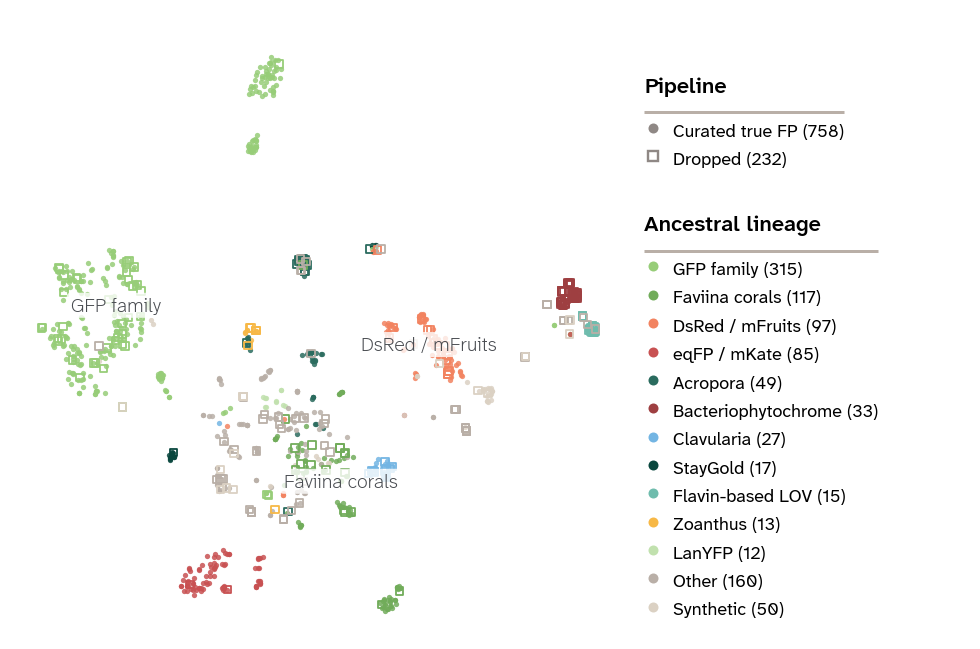

In [12]:
# Half_square is a third of the width this map had as a Full_wide panel, so everything drawn on
# it is scaled to match: the guide's 15pt is reserved for full-size panels, and 13 key entries
# beside a 300px map only fit at 9pt. Sizes live here so the map and its keys stay in step.
CALLOUT_FS, KEY_FS, KEY_TITLE_FS = 10, 9, 11
KEPT_S, DROPPED_S, SWATCH_S = 7, 14, 5


def label_families(ax, df, n_labels=3, fontsize=CALLOUT_FS):
    '''Annotate the largest lineages at the median of their points.

    Callout labels are Charcoal per the guide (text is only ever Black, White or Charcoal),
    so the colour association is carried by the key rather than by the label itself.
    Anchors are clamped toward the middle of the cloud to keep edge-hugging groups in frame,
    and only the few largest lineages are labelled -- any more and they collide.
    '''
    xlo, xhi = np.percentile(df.x, [12, 88])
    ylo, yhi = np.percentile(df.y, [12, 88])
    biggest = [f for f in df.family.value_counts().index if f not in SUPPORTING][:n_labels]
    for f in biggest:
        sub = df[df.family == f]
        ax.text(np.clip(sub.x.median(), xlo, xhi), np.clip(sub.y.median(), ylo, yhi),
                SHORT[f], ha="center", va="center", zorder=5,
                **{**ANNOTATION, "fontsize": fontsize},
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))


# One map instead of two, so it gets most of the width. The map is square and the key takes a
# third of the width, so the panel is only as tall as the square that leaves: any taller and the
# box aspect pays for it in blank bands above and below the map. The first row is a thin spacer
# that keeps the key titles clear of the top edge.
fig = plt.figure(figsize=(HALF_SQUARE * PX, 325 * PX))
gs = fig.add_gridspec(3, 2, width_ratios=(1, 0.48), height_ratios=(0.06, 0.22, 0.72),
                      left=0.02, right=0.95, top=0.95, bottom=0.02,
                      wspace=0.06, hspace=0.05)
ax_map = fig.add_subplot(gs[:, 0])
key_shape, key_lineage = fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[2, 1])


# Both take a swatch size because the keys below sit in a Half_square panel, while the keys of
# the later full-width figures reuse these helpers at the guide's size.
def dot(color, label, markersize=7):
    return Line2D([0], [0], marker="o", linestyle="", markersize=markersize,
                  markerfacecolor=color, markeredgecolor="none", label=label)


def open_square(color, label, markersize=7):
    return Line2D([0], [0], marker="s", linestyle="", markersize=markersize,
                  markerfacecolor="none", markeredgecolor=color,
                  markeredgewidth=1.2, label=label)


# Colour carries the lineage and marker shape carries the pipeline's verdict, so a single map
# shows both at once: filled circles are kept, open squares are dropped.
drop, keep = prot[~prot.is_true_fp], prot[prot.is_true_fp]
for f in fam_order:
    sub = keep[keep.family == f]
    ax_map.scatter(sub.x, sub.y, s=KEPT_S, color=FAM_COLOR[f], alpha=0.85, linewidths=0)
for f in fam_order:
    sub = drop[drop.family == f]
    ax_map.scatter(sub.x, sub.y, s=DROPPED_S, marker="s", facecolors="none",
                   edgecolors=FAM_COLOR[f], linewidths=0.9, zorder=3)
label_families(ax_map, prot)

# A short handle keeps the longest label inside the narrow key column.
KEY_TYPE = dict(fontsize=KEY_FS, title_fontsize=KEY_TITLE_FS, labelspacing=0.55,
                handlelength=1.0, handletextpad=0.6)

# Shape swatches are drawn in a neutral so they read as shape rather than as a lineage colour.
key_block(key_shape, [dot(str(apc.bark), f"Curated true FP ({len(keep)})", SWATCH_S),
                      open_square(str(apc.bark), f"Dropped ({len(drop)})", SWATCH_S)],
          "Pipeline", **KEY_TYPE)

# Ordering the key by how many proteins each lineage contributes makes it a ranking as well as
# a colour legend; the two supporting neutrals stay at the end, where they read as catch-alls.
fam_n = prot.family.value_counts()
key_order = (sorted((f for f in fam_order if f not in SUPPORTING), key=fam_n.get, reverse=True)
             + sorted(SUPPORTING, key=fam_n.get, reverse=True))
key_block(key_lineage, [dot(FAM_COLOR[f], f"{SHORT[f]} ({fam_n[f]})", SWATCH_S)
                        for f in key_order],
          "Ancestral lineage", **KEY_TYPE)

ax_map.set(xticks=[], yticks=[])
ax_map.set_box_aspect(1)
for side in ("left", "bottom"):
    ax_map.spines[side].set_visible(False)
fig.savefig("../figures/FPbase_t-SNE.svg")
plt.show()

**Figure 1. The curated peak set within FPbase sequence space.** t-SNE of the max-pooled ESM-2
embedding of all 990 sequenced FPbase proteins (standardize → PCA-50 → t-SNE, `init="pca"`,
perplexity 30). Colour gives the ancestral lineage; filled circles are the 758 sequences the peak
pipeline keeps and open squares the 232 it drops. The three largest lineages are labelled in
place; the key lists every lineage, largest first.

Reading shape against colour is the point of the figure: the open squares are not scattered at
random but concentrate in particular lineages. The bacteriophytochrome IR-FPs go almost entirely,
because their signal comes from bound biliverdin rather than from anything the sequence builds,
and the flavin-based LOV / miniSOG proteins go the same way. What survives is dominated by the
GFP-family and anthozoan-coral lineages, which is exactly the intent: proteins whose chromophore
is built by their own residues.

## 2. The curation funnel

Every stage of `build_dataset.py` and what it removes. Stages A and B are shared across all
three traits; stages C to E are specific to the peak target. Counts come straight from
`curate_meta.json`, so these bar charts cannot drift away from the data on disk.

Following the guide's "emphasize one group" pattern, the by-reason chart is a single Aegean
series with the one judgement-call rule — the cofactor exclusion — picked out in Amber.

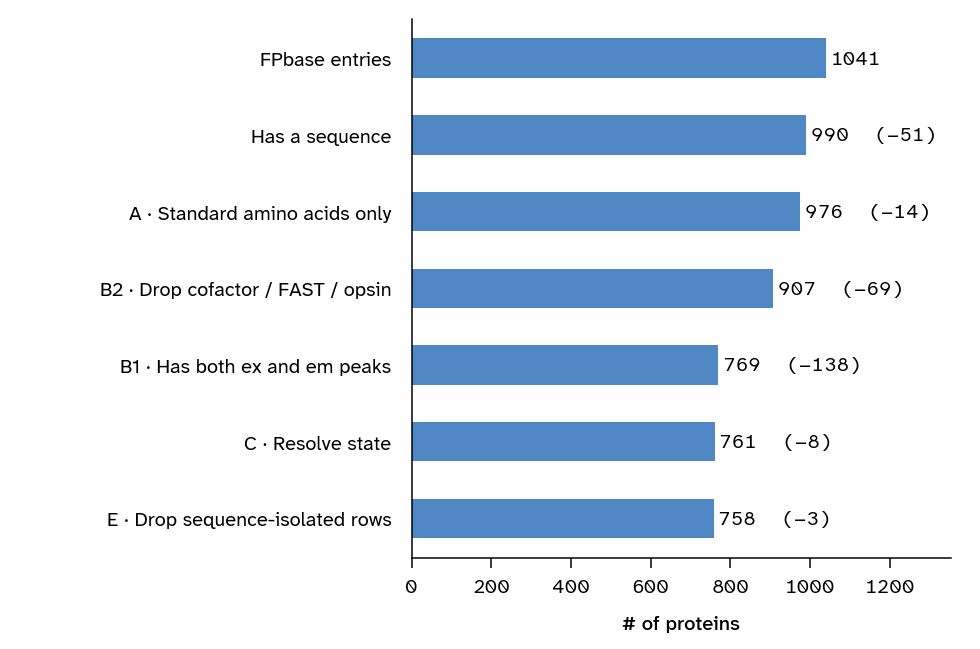

In [ ]:
cnt = cmeta["counts"]
res = cnt["resolve"]

n_entries = len(proteins)
n_seq     = n_entries - cnt["skipped_no_sequence"]
n_std     = n_seq - cnt["skipped_nonstandard_aa"]
n_genuine = n_std - cnt["skipped_exogenous"]
n_super   = n_genuine - cnt["skipped_no_emission_states"]
n_resolve = cnt["after_resolve"]
n_final   = cnt["curated"]

# Labels are written in their final case: apc capitalizes tick labels only when they are
# entirely lowercase, which would otherwise leave the ones containing acronyms out of step.
funnel = [
    ("FPbase entries",                    n_entries, None),
    ("Has a sequence",                    n_seq,     cnt["skipped_no_sequence"]),
    ("Standard amino acids only",     n_std,     cnt["skipped_nonstandard_aa"]),
    ("Drop cofactor / FAST / opsin", n_genuine, cnt["skipped_exogenous"]),
    ("Has both ex and em peaks",     n_super,   cnt["skipped_no_emission_states"]),
    ("Resolve state",                 n_resolve, n_super - n_resolve),
    ("Drop sequence-isolated rows",   n_final,   cnt["nn_dropped"]),
]

# A Half_square panel spends more than a third of its width on the category labels, so both
# funnel charts step down from the guide's 15pt the way the Figure 1 keys do.
FUNNEL_FS = 10
FUNNEL_NUM = {**NUMBERS, "fontsize": FUNNEL_FS}
# barh measures bar height in category units, so the two charts share a bar thickness only if the
# height scales with the number of bars. 0.66 over the nine drop reasons is the reference.
BAR_UNIT = 0.66 / 9


def style_funnel(ax, xlabel):
    apc.mpl.style_plot(ax, monospaced_axes="x", categorical_axes="y")
    ax.set_xlabel(xlabel, fontsize=FUNNEL_FS)
    ax.tick_params(labelsize=FUNNEL_FS)


fig, ax = figure_px(HALF_SQUARE, 325)
fig.subplots_adjust(left=0.42, right=0.97, top=0.97, bottom=0.14)

y = np.arange(len(funnel))
ax.barh(y, [v for _, v, _ in funnel], color=HIGHLIGHT, height=BAR_UNIT * len(funnel))
ax.set_yticks(y, [label for label, _, _ in funnel])
ax.invert_yaxis()
for i, (_, v, d) in enumerate(funnel):
    ax.text(v + 12, i, f"{v}" if d in (None, 0) else f"{v}  (−{d})",
            va="center", **FUNNEL_NUM)
ax.set_xlim(0, n_entries * 1.30)
style_funnel(ax, "# of proteins")
fig.savefig("../figures/FPbase_cleaning_funnel.svg")
plt.show()

**Figure 2. What survives each stage of the pipeline.** Proteins remaining after every stage of
`build_dataset.py`, with the loss at each step in parentheses. Two stages account for most of the
283 entries that never reach the curated set; Figure 3 breaks the losses out by reason.

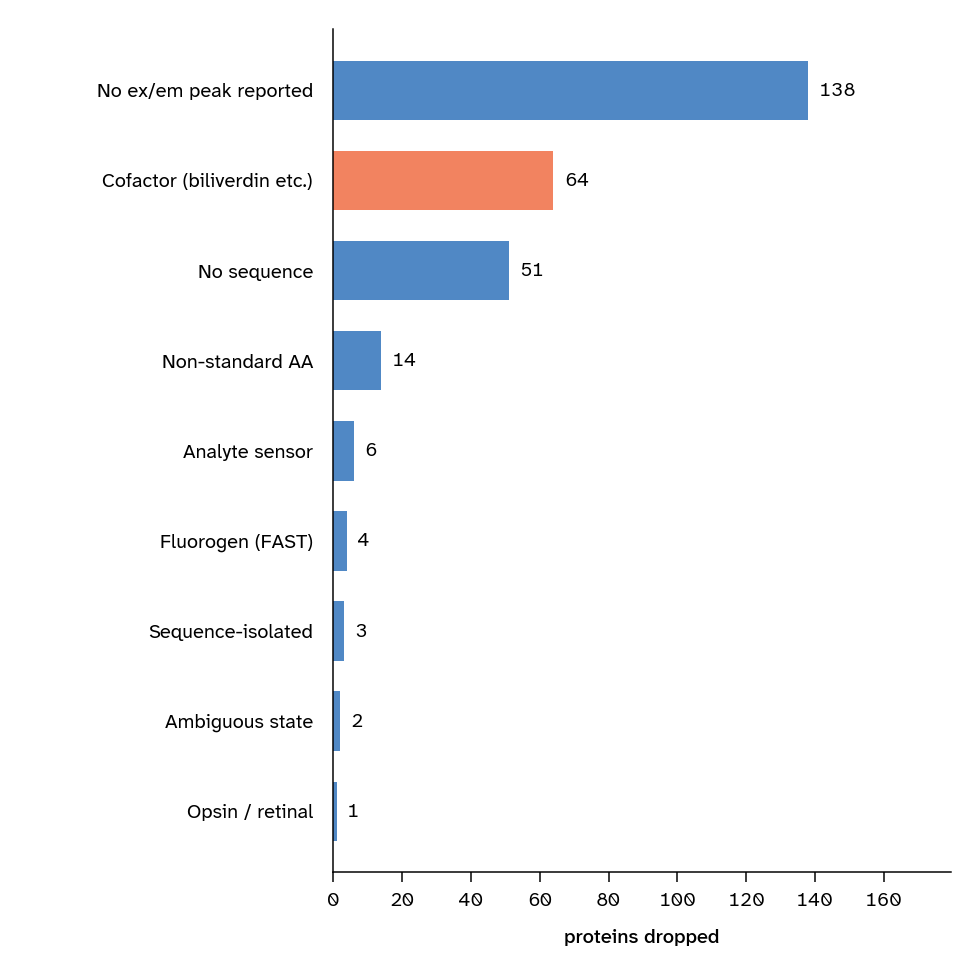

In [15]:
COFACTOR = "Cofactor (biliverdin etc.)"
dropped = cmeta["dropped_names"]
# `exogenous_manual_irfp` is not a separate criterion: it is the same bound-cofactor rule reached
# by a different route. iFP2.0 is a biliverdin bacteriophytochrome whose FPbase `cofactor` field
# was left blank, so a hand-maintained name list catches it. Counting it as its own bar would
# imply a distinct exclusion, so fold it in with the properly tagged bilin proteins.
reasons = {
    "No ex/em peak reported": cnt["skipped_no_emission_states"],
    COFACTOR:                 (len(dropped.get("exogenous_cofactor", []))
                               + len(dropped.get("exogenous_manual_irfp", []))),
    "No sequence":            cnt["skipped_no_sequence"],
    "Non-standard AA":        cnt["skipped_nonstandard_aa"],
    "Analyte sensor":         res.get("analyte_sensor", 0),
    "Fluorogen (FAST)":       len(dropped.get("exogenous_fluorogen", [])),
    "Sequence-isolated":      cnt["nn_dropped"],
    "Ambiguous state":        res.get("drop_ambiguous", 0),
    "Opsin / retinal":        len(dropped.get("exogenous_opsin", [])),
}
reasons = dict(sorted(reasons.items(), key=lambda kv: kv[1], reverse=True))
assert sum(reasons.values()) == n_entries - n_final, "reason breakdown must account for every drop"

fig, ax = figure_px(HALF_SQUARE, HALF_SQUARE)
fig.subplots_adjust(left=0.34, right=0.97, top=0.97, bottom=0.11)

ry = np.arange(len(reasons))
ax.barh(ry, list(reasons.values()),
        color=[CONTRAST if k == COFACTOR else HIGHLIGHT for k in reasons],
        height=BAR_UNIT * len(reasons))
ax.set_yticks(ry, list(reasons))
ax.invert_yaxis()
for i, v in enumerate(reasons.values()):
    ax.text(v + 3, i, str(v), va="center", **FUNNEL_NUM)
ax.set_xlim(0, max(reasons.values()) * 1.30)
style_funnel(ax, "proteins dropped")
plt.show()

**Figure 3. Where the other 283 proteins go.** A complete by-reason accounting of every dropped
protein; the cofactor rule is highlighted.

Most of the attrition is mundane bookkeeping: the largest single bucket is simply proteins with no
reported excitation/emission pair, followed by entries with no sequence at all. Neither can supply
a training example, so neither is a judgement call.

The interesting exclusion is the cofactor rule, the second-largest bucket. Those are overwhelmingly
the biliverdin near-infrared proteins engineered from bacterial phytochromes — the lineage that sits
apart in Figure 1. They fluoresce only when a bilin is supplied, so their emission wavelength is
not a property the amino-acid sequence determines, and a sequence-to-peak model would be learning a
label its input cannot explain. The remaining rules (non-standard residues, analyte sensors whose
peak depends on pH or calcium, ambiguous multi-state entries) each remove only a handful.

One of those 64 cofactor drops does not come from FPbase's `cofactor` field. iFP2.0 is a
*Deinococcus radiodurans* bacteriophytochrome emitting at 711 nm, but its FPbase record leaves the
cofactor field blank, so the tag-based test misses it and a one-name list in `build_dataset.py`
catches it instead. It is counted here with the tagged bilin proteins because the reason is
identical — the chromophore is supplied, not built — and only the bookkeeping route differs.

## 3. Excitation and emission across the curated set

A scatter of the 758 targets with a marginal histogram on each axis.

Points are shaded by emission wavelength on the Arcadia **magma** gradient — one of the guide's
sequential gradients for dots — running dark violet at the blue end to warm tan at the red end.
In this figure that shading simply restates the y-axis, so no colour key is needed here; the same
scale is carried into sections 4 and 5, where the axes are principal components and it does real
work. The top of the ramp is trimmed so the reddest proteins stay distinct from the page.

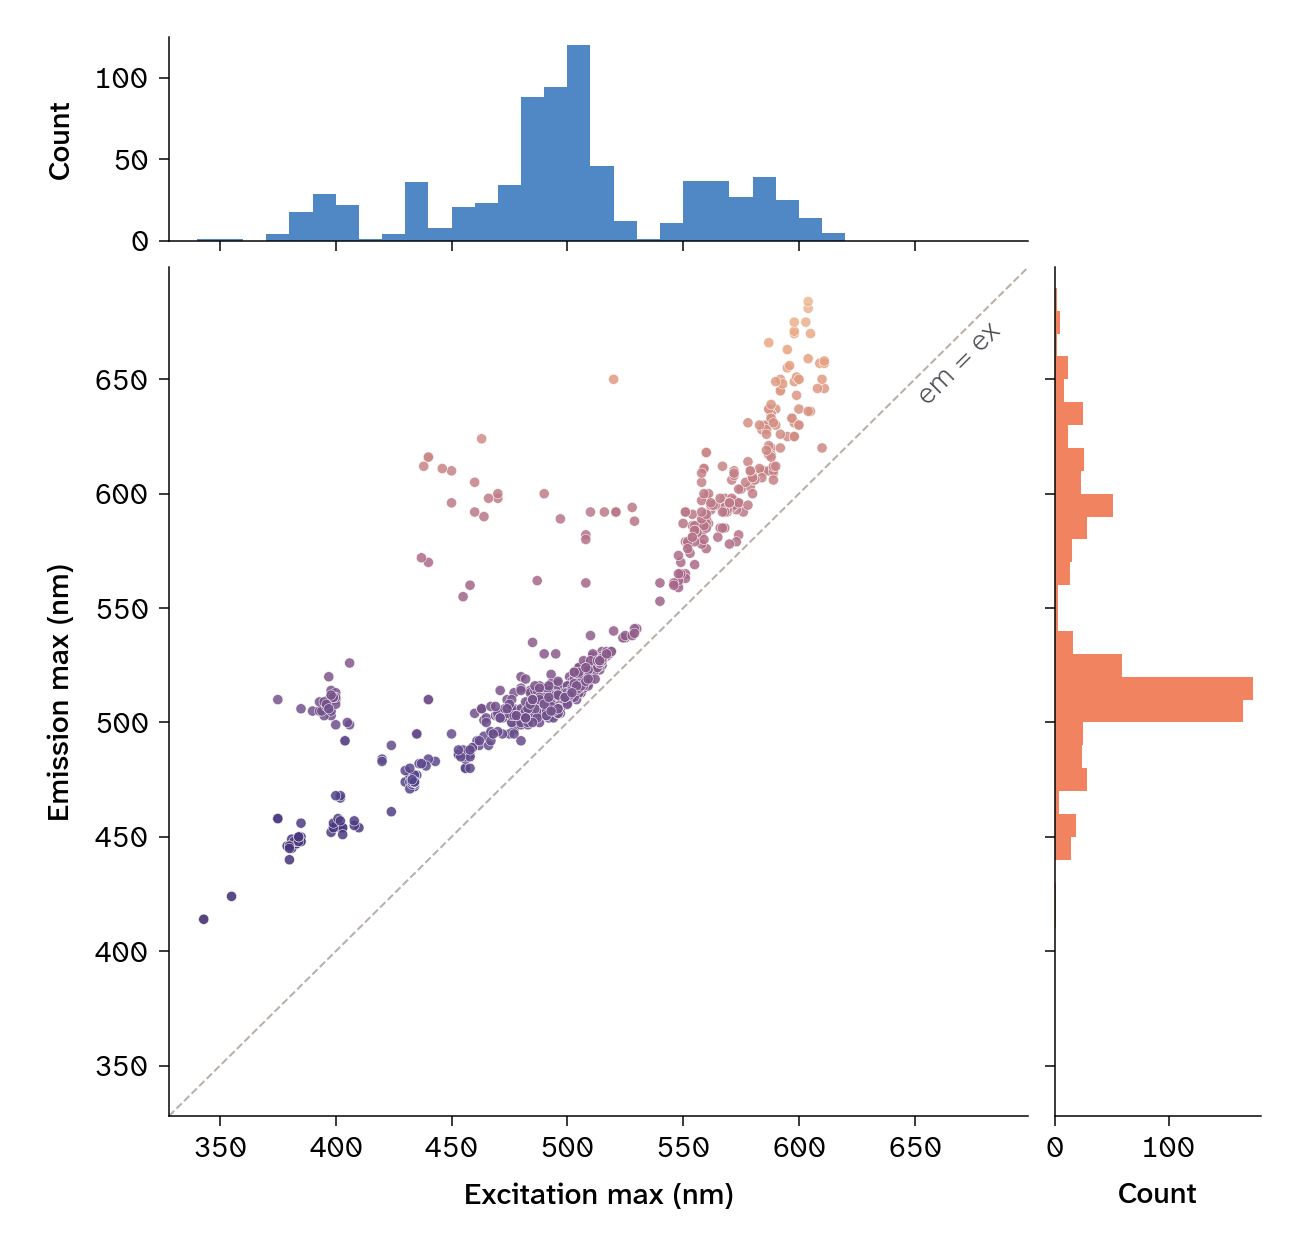

excitation  343–611 nm   median 499
emission    414–684 nm   median 514
Stokes shift  median 24 nm, IQR 14–41 nm, max 176 nm


In [23]:
ex = curated.ex_max.to_numpy()
em = curated.em_max.to_numpy()
stokes = em - ex

# One emission scale shared by every figure below, so a colour means the same thing throughout.
EM_NORM = Normalize(vmin=em.min(), vmax=em.max())


def em_colors(values):
    return EM_CMAP(EM_NORM(np.asarray(values)))


def emission_colorbar(fig, cax, orientation="vertical", ticks_on_top=False):
    bar = fig.colorbar(plt.cm.ScalarMappable(norm=EM_NORM, cmap=EM_CMAP),
                       cax=cax, orientation=orientation)
    if ticks_on_top:
        # A bar sitting directly above a panel has to carry its ticks on the far side. Flip before
        # the monospaced font is applied, because moving the ticks rebuilds their labels.
        cax.xaxis.set_ticks_position("top")
        cax.xaxis.set_label_position("top")
    bar.set_label("Emission max (nm)")
    bar.outline.set_visible(False)
    apc.mpl.set_colorbar_ticklabel_monospaced(cax)
    return bar


pt_colors = em_colors(em)

fig = plt.figure(figsize=(FLOAT * PX, 620 * PX))
gs = fig.add_gridspec(2, 2, width_ratios=(5, 1.2), height_ratios=(1.2, 5),
                      left=0.13, right=0.97, top=0.97, bottom=0.10, wspace=0.05, hspace=0.05)
ax = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax)

ax.scatter(ex, em, s=26, c=pt_colors, alpha=0.85, linewidths=0.3, edgecolors="white")
lo, hi = min(ex.min(), em.min()) - 15, max(ex.max(), em.max()) + 15
ax.plot([lo, hi], [lo, hi], ls="--", lw=1, color=NEUTRAL, zorder=0)
ax.text(hi - 10, hi - 30, "em = ex", rotation=45, rotation_mode="anchor",
        ha="right", va="bottom", **ANNOTATION)
ax.set(xlim=(lo, hi), ylim=(lo, hi),
       xlabel="excitation max (nm)", ylabel="emission max (nm)")

bins = np.arange(330, 700, 10)
ax_top.hist(ex, bins=bins, color=HIGHLIGHT)
ax_top.set_ylabel("count")
ax_top.tick_params(axis="x", labelbottom=False)
ax_right.hist(em, bins=bins, color=CONTRAST, orientation="horizontal")
ax_right.set_xlabel("count")
ax_right.tick_params(axis="y", labelleft=False)

for a in (ax, ax_top, ax_right):
    apc.mpl.style_plot(a, monospaced_axes="both")
plt.show()

print(f"excitation  {ex.min():.0f}–{ex.max():.0f} nm   median {np.median(ex):.0f}")
print(f"emission    {em.min():.0f}–{em.max():.0f} nm   median {np.median(em):.0f}")
print(f"Stokes shift  median {np.median(stokes):.0f} nm, "
      f"IQR {np.percentile(stokes, 25):.0f}–{np.percentile(stokes, 75):.0f} nm, "
      f"max {stokes.max():.0f} nm")

**Figure 4. Excitation and emission maxima of the 758 curated proteins,** with marginal
histograms (excitation in Aegean, emission in Amber) and the `em = ex` diagonal for reference.
Points are shaded by emission wavelength on the magma gradient, which here repeats the y-axis.

Both marginals are strongly multi-modal rather than smooth: the dataset clumps into the
cyan/green, yellow, orange and red groups that protein engineering has actually explored, with
thin coverage in between. Almost everything hugs the diagonal at a modest offset, since a typical
FP emits 20–30 nm to the red of where it absorbs. The handful of points far above the diagonal
are the large-Stokes-shift proteins, which matter here because they are rare — a model has very
few examples from which to learn that behaviour.

## 4. PCA on the peak targets

The target space is only two-dimensional, so PCA here is a rotation rather than a reduction. It
is still worth doing, because the rotation is interpretable: excitation and emission are highly
correlated, so the first component becomes an overall "colour" axis and the second becomes
essentially the Stokes shift.

correlation(ex, em) = 0.849
PC1:  92.5% variance   loadings  ex +0.739   em +0.674
PC2:   7.5% variance   loadings  ex -0.674   em +0.739
correlation(PC2, Stokes shift) = +0.987


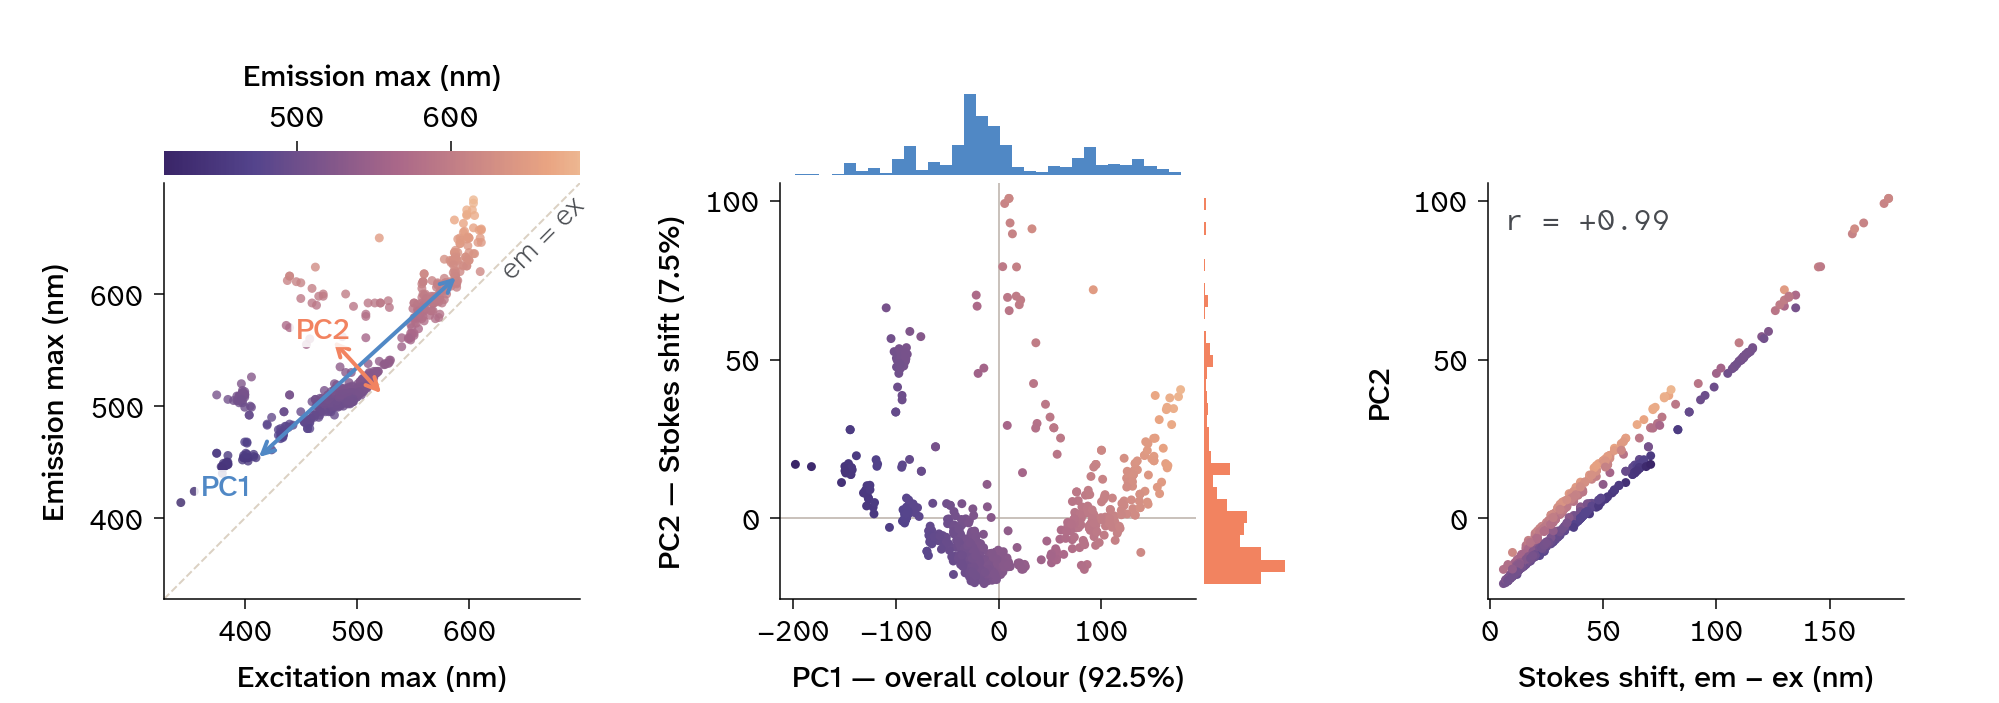

In [24]:
XY = np.column_stack([ex, em])
pk = PCA(n_components=2, random_state=RNG_SEED)
S = pk.fit_transform(XY)
evr = pk.explained_variance_ratio_

print(f"correlation(ex, em) = {np.corrcoef(ex, em)[0, 1]:.3f}")
for i, (v, comp) in enumerate(zip(evr, pk.components_), start=1):
    print(f"PC{i}: {v:6.1%} variance   loadings  ex {comp[0]:+.3f}   em {comp[1]:+.3f}")
r_stokes = np.corrcoef(S[:, 1], stokes)[0, 1]
print(f"correlation(PC2, Stokes shift) = {r_stokes:+.3f}")

# Three square panels, the middle one framed by marginal histograms. The panels are placed by hand
# in style-guide pixels instead of by gridspec: set_box_aspect squares an axes by shrinking it
# inside its cell, which would leave B's square out of register with the marginals beside it.
PANEL, STRIP, PAD, GAP = 208, 42, 4, 100
LEFT, BOTTOM, CBAR_H = 82, 52, 12
TOP = 46                              # room for the colorbar's ticks and label above panel A
FIG_W, FIG_H = FULL_WIDE, BOTTOM + PANEL + PAD + STRIP + TOP

fig = plt.figure(figsize=(FIG_W * PX, FIG_H * PX))


def px_axes(x, y, w, h, **kwargs):
    '''An axes placed in style-guide pixels from the bottom-left corner of the figure.'''
    return fig.add_axes([x / FIG_W, y / FIG_H, w / FIG_W, h / FIG_H], **kwargs)


x_b = LEFT + PANEL + GAP
x_c = x_b + PANEL + PAD + STRIP + GAP
ax_a = px_axes(LEFT, BOTTOM, PANEL, PANEL)
ax_b = px_axes(x_b, BOTTOM, PANEL, PANEL)
ax_b_top = px_axes(x_b, BOTTOM + PANEL + PAD, PANEL, STRIP, sharex=ax_b)
ax_b_right = px_axes(x_b + PANEL + PAD, BOTTOM, STRIP, PANEL, sharey=ax_b)
ax_c = px_axes(x_c, BOTTOM, PANEL, PANEL)

# A: raw space with the principal axes drawn on top
lo, hi = min(ex.min(), em.min()) - 15, max(ex.max(), em.max()) + 15
ax_a.scatter(ex, em, s=20, c=pt_colors, alpha=0.8, linewidths=0)
# The em = ex reference sits under the arrows: PC1 runs parallel to it, a hair above.
ax_a.plot([lo, hi], [lo, hi], ls="--", lw=1, color=NEUTRAL_SOFT, zorder=0)
ax_a.text(hi - 8, hi - 8, "em = ex", rotation=45, rotation_mode="anchor",
          ha="right", va="top", **ANNOTATION)
# Both axes carry the same range, so the reference really is at 45° and the arrows are undistorted
ax_a.set(xlim=(lo, hi), ylim=(lo, hi),
         xlabel="excitation max (nm)", ylabel="emission max (nm)")
mu = XY.mean(0)
sd = np.sqrt(pk.explained_variance_)
# one shared scale, sized so the longer axis spans ~1/3 of the panel and both stay in frame
arrow_scale = 0.33 * (hi - lo) / sd.max()
# PC1 is labelled at its lower end, where the panel is empty; PC2 at its upper end
label_end = (-1, +1)
for i, (comp, s) in enumerate(zip(pk.components_, sd)):
    d = comp * s * arrow_scale
    col = HIGHLIGHT if i == 0 else CONTRAST
    ax_a.annotate("", xy=mu + d, xytext=mu - d,
                  arrowprops=dict(arrowstyle="<->", lw=2, color=col))
    ax_a.text(*(mu + d * 1.3 * label_end[i]), f"PC{i + 1}", ha="center", va="center",
              fontsize=15, fontweight="medium", color=col, zorder=6,
              bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))

# B: PC space, with the distribution along each component in the margins
ax_b.scatter(S[:, 0], S[:, 1], s=20, c=pt_colors, alpha=1, linewidths=0)
ax_b.axhline(0, lw=0.75, color=NEUTRAL, zorder=0)
ax_b.axvline(0, lw=0.75, color=NEUTRAL, zorder=0)
ax_b.set(xlabel=f"PC1 — overall colour ({evr[0]:.1%})",
         ylabel=f"PC2 — Stokes shift ({evr[1]:.1%})")
# Each marginal takes the colour of the arrow it summarises in panel A. They are drawn bare: in a
# 42px strip the shape of the distribution is the message and a count axis would only crowd it.
ax_b_top.hist(S[:, 0], bins=32, color=HIGHLIGHT)
ax_b_right.hist(S[:, 1], bins=32, color=CONTRAST, orientation="horizontal")
for a in (ax_b_top, ax_b_right):
    a.set_axis_off()

# C: PC2 really is the Stokes shift
ax_c.scatter(stokes, S[:, 1], s=20, c=pt_colors, alpha=1, linewidths=0)
ax_c.set(xlabel="Stokes shift, em − ex (nm)", ylabel="PC2")
ax_c.text(0.04, 0.94, f"r = {r_stokes:+.2f}", transform=ax_c.transAxes,
          ha="left", va="top", **NUMBER_NOTE)

for ax in (ax_a, ax_b, ax_c):
    apc.mpl.style_plot(ax, monospaced_axes="both")
    ax.locator_params(nbins=5)
# The emission scale lies over panel A, in the same band the marginals occupy over B, so it costs
# the figure no width. Its ticks ride on top, leaving the bar itself against the panel.
emission_colorbar(fig, px_axes(LEFT, BOTTOM + PANEL + PAD, PANEL, CBAR_H),
                  orientation="horizontal", ticks_on_top=True)
fig.savefig("../figures/PCA_peaks.svg")
plt.show()

**Figure 5. The (ex, em) target space rotated onto its principal axes.** **(A)** The raw targets
with the two principal axes overlaid, scaled to their standard deviations; both axes carry the same
range, so the `em = ex` diagonal is a true 45° reference. **(B)** The same points in PC space, with
the distribution along each component in the margins — PC1 in Aegean and PC2 in Amber, the colours
of the arrows they come from. **(C)** PC2 against the directly computed Stokes shift.

PC1 absorbs the overwhelming majority of the variance with near-equal positive loadings on both
peaks: it is simply "how red is this protein", and panel A shows its arrow running parallel to
`em = ex`. PC2 is the residual after that shared movement is removed, and its near-perfect
correlation with `em − ex` confirms it is the Stokes shift. The marginals make the asymmetry plain:
PC1 spreads over the same multi-modal clumps the raw peaks show in Figure 4, while PC2 piles up
near zero with a thin tail of large-shift proteins. The
practical reading is that predicting an FP's two peaks is close to a one-dimensional problem plus
a small, harder correction — and that correction is where the large-Stokes-shift designs live.

In [ ]:
# A scratch comparison for Figure 5, not part of the narrative: the same three panels with every
# point in a single colour, to see how much the emission gradient is really carrying. The layout
# constants, the data and the annotations all come from the figure cell above, so only the point
# colour and the missing colorbar differ. Nothing here is exported.
FLAT_COLOR = str(apc.bark)            # swap in HIGHLIGHT for the guide's single-series colour

fig = plt.figure(figsize=(FIG_W * PX, FIG_H * PX))


def flat_axes(x, y, w, h, **kwargs):
    '''px_axes from the figure cell above, bound to this test figure.'''
    return fig.add_axes([x / FIG_W, y / FIG_H, w / FIG_W, h / FIG_H], **kwargs)


ax_a = flat_axes(LEFT, BOTTOM, PANEL, PANEL)
ax_b = flat_axes(x_b, BOTTOM, PANEL, PANEL)
ax_b_top = flat_axes(x_b, BOTTOM + PANEL + PAD, PANEL, STRIP, sharex=ax_b)
ax_b_right = flat_axes(x_b + PANEL + PAD, BOTTOM, STRIP, PANEL, sharey=ax_b)
ax_c = flat_axes(x_c, BOTTOM, PANEL, PANEL)

# A: raw space with the principal axes drawn on top
ax_a.scatter(ex, em, s=20, c=FLAT_COLOR, alpha=0.8, linewidths=0)
ax_a.plot([lo, hi], [lo, hi], ls="--", lw=1, color=NEUTRAL_SOFT, zorder=0)
ax_a.text(hi - 8, hi - 8, "em = ex", rotation=45, rotation_mode="anchor",
          ha="right", va="top", **ANNOTATION)
ax_a.set(xlim=(lo, hi), ylim=(lo, hi),
         xlabel="excitation max (nm)", ylabel="emission max (nm)")
for i, (comp, s) in enumerate(zip(pk.components_, sd)):
    d = comp * s * arrow_scale
    col = HIGHLIGHT if i == 0 else CONTRAST
    ax_a.annotate("", xy=mu + d, xytext=mu - d,
                  arrowprops=dict(arrowstyle="<->", lw=2, color=col))
    ax_a.text(*(mu + d * 1.3 * label_end[i]), f"PC{i + 1}", ha="center", va="center",
              fontsize=15, fontweight="medium", color=col, zorder=6,
              bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))

# B: PC space, with the distribution along each component in the margins
ax_b.scatter(S[:, 0], S[:, 1], s=20, c=FLAT_COLOR, alpha=1, linewidths=0)
ax_b.axhline(0, lw=0.75, color=NEUTRAL, zorder=0)
ax_b.axvline(0, lw=0.75, color=NEUTRAL, zorder=0)
ax_b.set(xlabel=f"PC1 — overall colour ({evr[0]:.1%})",
         ylabel=f"PC2 — Stokes shift ({evr[1]:.1%})")
ax_b_top.hist(S[:, 0], bins=32, color=HIGHLIGHT)
ax_b_right.hist(S[:, 1], bins=32, color=CONTRAST, orientation="horizontal")
for a in (ax_b_top, ax_b_right):
    a.set_axis_off()

# C: PC2 really is the Stokes shift
ax_c.scatter(stokes, S[:, 1], s=20, c=FLAT_COLOR, alpha=1, linewidths=0)
ax_c.set(xlabel="Stokes shift, em − ex (nm)", ylabel="PC2")
ax_c.text(0.04, 0.94, f"r = {r_stokes:+.2f}", transform=ax_c.transAxes,
          ha="left", va="top", **NUMBER_NOTE)

for ax in (ax_a, ax_b, ax_c):
    apc.mpl.style_plot(ax, monospaced_axes="both")
    ax.locator_params(nbins=5)
plt.show()

## 5. PCA on the sequence embeddings of the spectrally-characterised subset

Now restrict to the curated proteins that additionally have **measured excitation and emission
curves** in FPbase, and run PCA on their max-pooled ESM-2 embeddings. This is the subset a model
conditioned on full spectra could be trained on, so it is worth knowing how much of the sequence
space it still covers.

In [10]:
spectra = json.load(open(SPECTRA))
with_curves = {
    rec.get("slug") for rec in spectra
    if {"excitation", "emission"} <= {s.get("spectrum_type") for s in rec.get("spectra", [])}
}

seq_to_row = {s: i for i, s in enumerate(prot.seq)}
curated = curated.assign(
    has_spectra=curated.slug.isin(with_curves),
    row=curated.seq.map(seq_to_row),
)
assert curated.row.notna().all(), "every curated sequence should be in the embedding table"
curated["row"] = curated.row.astype(int)

sub = curated[curated.has_spectra]
Zsub = Z[sub.row.to_numpy()]
print(f"{len(with_curves)} FPbase proteins have both ex and em curves")
print(f"{len(sub)} of the {len(curated)} curated proteins are in that set "
      f"({len(sub) / len(curated):.0%})")

450 FPbase proteins have both ex and em curves
382 of the 758 curated proteins are in that set (50%)


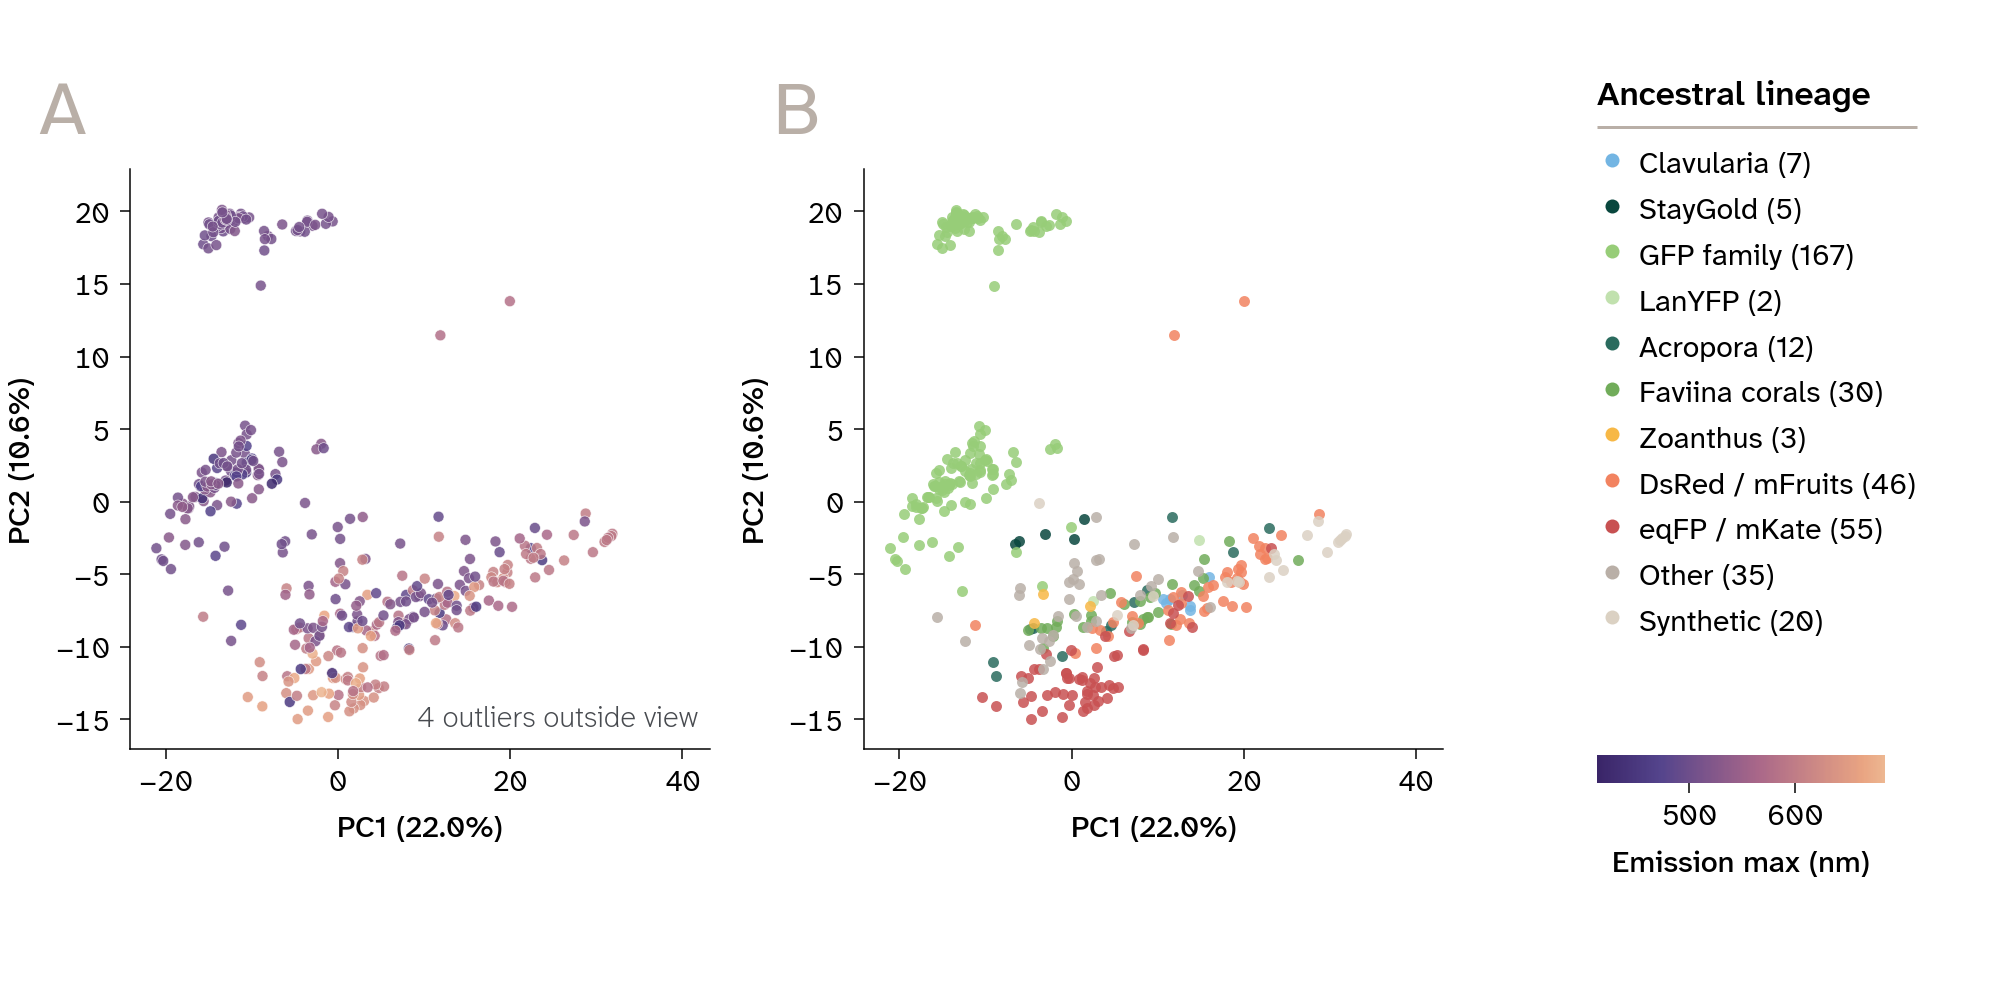

clipped from the view:
  BDFP2.0                      PC1    +66.8  PC2    +20.4
  RCaMP                        PC1   +114.3  PC2    +52.0
  vsfGFP-0                     PC1   +123.9  PC2    +58.3
  vsfGFP-9                     PC1   +123.8  PC2    +58.5


In [11]:
ps = PCA(n_components=min(50, len(sub) - 1), random_state=RNG_SEED)
P = ps.fit_transform(StandardScaler().fit_transform(Zsub))
evr_s = ps.explained_variance_ratio_

sub_em = sub.em_max.to_numpy()
sub_colors = em_colors(sub_em)
sub_fam = prot.family.to_numpy()[sub.row.to_numpy()]


def robust_lims(v, pad=0.08):
    '''Axis limits covering the bulk, so a few extreme points cannot flatten the cloud.'''
    lo, hi = np.percentile(v, [1, 99])
    margin = (hi - lo) * pad
    return lo - margin, hi + margin


xlim, ylim = robust_lims(P[:, 0]), robust_lims(P[:, 1])
off = ((P[:, 0] < xlim[0]) | (P[:, 0] > xlim[1]) |
       (P[:, 1] < ylim[0]) | (P[:, 1] > ylim[1]))

FIG5_H = 500
fig = plt.figure(figsize=(FULL_WIDE * PX, FIG5_H * PX))
gs = fig.add_gridspec(1, 3, width_ratios=(1, 1, 0.66),
                      left=0.065, right=0.99, top=0.92, bottom=0.16, wspace=0.30)
ax_a, ax_b, key_ax = (fig.add_subplot(gs[0, i]) for i in range(3))

ax_a.scatter(P[:, 0], P[:, 1], s=30, c=sub_colors, alpha=0.85,
             linewidths=0.3, edgecolors="white")
if off.any():
    ax_a.text(0.98, 0.03, f"{off.sum()} outliers outside view", transform=ax_a.transAxes,
              ha="right", va="bottom", **ANNOTATION)
panel_letter(ax_a, "A")

present = [f for f in fam_order if (sub_fam == f).any()]
for f in present:
    m = sub_fam == f
    ax_b.scatter(P[m, 0], P[m, 1], s=30, color=FAM_COLOR[f], alpha=0.85, linewidths=0)
panel_letter(ax_b, "B")

lineage_key = key_block(key_ax, [dot(FAM_COLOR[f], f"{SHORT[f]} ({int((sub_fam == f).sum())})")
                                 for f in present],
                        "Ancestral lineage")

for ax in (ax_a, ax_b):
    ax.set(xlim=xlim, ylim=ylim,
           xlabel=f"PC1 ({evr_s[0]:.1%})", ylabel=f"PC2 ({evr_s[1]:.1%})")
    ax.set_box_aspect(1)
    apc.mpl.style_plot(ax, monospaced_axes="both")

# The emission scale belongs with the lineage key rather than between the panels, where its
# label would run into panel B. Position it off the drawn key so the gap is exact.
fig.canvas.draw()
key_box = lineage_key.get_window_extent().transformed(fig.transFigure.inverted())
emission_colorbar(fig, fig.add_axes([key_box.x0, key_box.y0 - 74 / FIG5_H,
                                     key_box.width * 0.9, 14 / FIG5_H]),
                  orientation="horizontal")
plt.show()

if off.any():
    print("clipped from the view:")
    for nm, p1, p2 in zip(sub.name.to_numpy()[off], P[off, 0], P[off, 1]):
        print(f"  {nm:<28s} PC1 {p1:+8.1f}  PC2 {p2:+8.1f}")

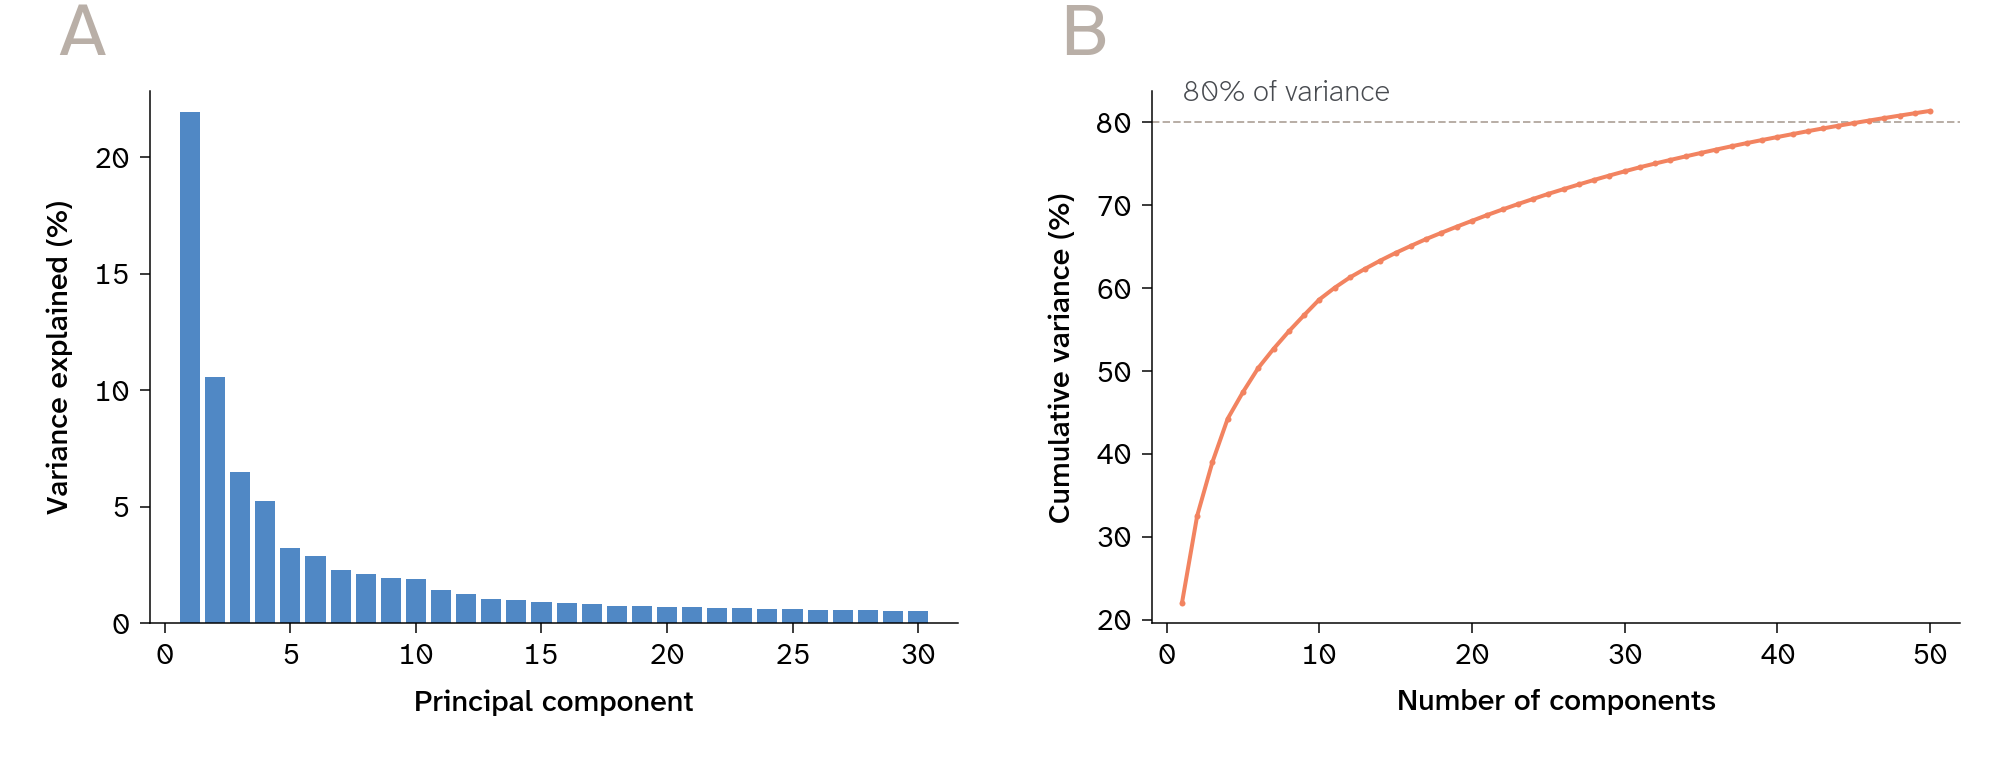

PC1+PC2 capture 32.5% of the variance; 46 components are needed to reach 80%
correlation(PC1, emission) = +0.323
correlation(PC2, emission) = -0.434
correlation(PC3, emission) = +0.319


In [12]:
fig, axes = figure_px(FULL_WIDE, 380, ncols=2)
fig.subplots_adjust(left=0.075, right=0.98, top=0.88, bottom=0.18, wspace=0.24)

k = min(30, len(evr_s))
axes[0].bar(np.arange(1, k + 1), evr_s[:k] * 100, color=HIGHLIGHT)
axes[0].set(xlabel="principal component", ylabel="variance explained (%)")
panel_letter(axes[0], "A")

n80 = int(np.searchsorted(np.cumsum(evr_s), 0.80) + 1)
axes[1].plot(np.arange(1, len(evr_s) + 1), np.cumsum(evr_s) * 100,
             marker="o", ms=3, color=CONTRAST)
axes[1].axhline(80, ls="--", lw=1, color=NEUTRAL, zorder=0)
axes[1].text(1, 82, "80% of variance", ha="left", va="bottom", **ANNOTATION)
axes[1].set(xlabel="number of components", ylabel="cumulative variance (%)")
panel_letter(axes[1], "B")

for ax in axes:
    apc.mpl.style_plot(ax, monospaced_axes="both")
plt.show()

print(f"PC1+PC2 capture {evr_s[:2].sum():.1%} of the variance; "
      f"{n80} components are needed to reach 80%")
for i in range(3):
    print(f"correlation(PC{i + 1}, emission) = {np.corrcoef(P[:, i], sub_em)[0, 1]:+.3f}")

**Figure 6. Sequence-embedding PCA over the 382 curated proteins with measured spectra.**
**(A)** PC1/PC2 coloured by emission wavelength. **(B)** The same projection coloured by ancestral
lineage. **Figure 7.** Scree **(A)** and cumulative variance **(B)** for the same decomposition.

The leading components organise the set by **lineage**, not by emission. Panel 6B resolves into
clean single-coloured blocks — the *Aequorea* GFP proteins occupy their own territory, the
anthozoan reds another — whereas 6A shows those same blocks spanning much of the emission scale
internally: the eqFP/mScarlet and DsRed regions run from mid-green through to deep red. Note that
this contrast survives even though a lineage's key colour is itself keyed to its founder's
emission, because members scatter far from that founder — the *Discosoma* lineage alone spans
452 to 649 nm. Emission correlates only weakly with any of the first three components
(|r| ≤ 0.43), and what correlation exists is largely inherited from the fact that lineages are
themselves emission-biased.

This is what one should expect. ESM-2 is trained on sequence alone, so it encodes evolutionary
relatedness; within a family a handful of chromophore-pocket substitutions can move the emission
peak a long way while barely moving the embedding. The scree plot says the same thing from a
different angle: it is flat-tailed, needing dozens of components to reach 80% of the variance.

Together these argue that sequence → peak is not a mapping a few linear directions will capture,
which is why the pipeline feeds per-residue embeddings to a trained model rather than regressing
on a handful of principal components.

The four points clipped from panel 6's view are worth noting: `RCaMP`, `vsfGFP-0`, `vsfGFP-9` and
`BDFP2.0` are all fusion constructs, carrying a sensing domain grafted onto the barrel. They are
outliers in sequence space because they are much longer than a bare FP, not because their
photophysics is unusual.